# imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

from xgboost import XGBClassifier, plot_importance

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [8]:
df = pd.read_csv('/kaggle/input/datasets/rohulaminlabid/iotid20-dataset/IoT Network Intrusion Dataset.csv')

print("Original shape:", df.shape)
print(df['Sub_Cat'].value_counts())

# Keep only ARP Spoofing and Normal traffic
df = df[df['Sub_Cat'].isin(['MITM ARP Spoofing', 'Normal'])]
print("\nFiltered shape (ARP Spoofing + Normal only):", df.shape)
print(df['Sub_Cat'].value_counts())

Original shape: (625783, 86)
Sub_Cat
Mirai-UDP Flooding       183554
Mirai-Hostbruteforceg    121181
DoS-Synflooding           59391
Mirai-HTTP Flooding       55818
Mirai-Ackflooding         55124
Scan Port OS              53073
Normal                    40073
MITM ARP Spoofing         35377
Scan Hostport             22192
Name: count, dtype: int64

Filtered shape (ARP Spoofing + Normal only): (75450, 86)
Sub_Cat
Normal               40073
MITM ARP Spoofing    35377
Name: count, dtype: int64


# preprocessing

In [9]:
# Drop duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Drop non-feature columns
drop_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Encode target: Normal vs ARP_Spoofing
target_col = 'Sub_Cat'
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
print("Classes:", le.classes_)  # 0 = ARP_Spoofing, 1 = Normal (alphabetical)

Classes: ['MITM ARP Spoofing' 'Normal']


# Features engineering

In [10]:
X = df.drop(columns=['Label', 'Cat', 'Sub_Cat'], errors='ignore')
y = df[target_col]

# Drop ALL non-numeric columns automatically
non_numeric = X.select_dtypes(exclude=['number']).columns.tolist()
print("Dropping non-numeric columns:", non_numeric)
X.drop(columns=non_numeric, inplace=True)

from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=0.01)
X = pd.DataFrame(sel.fit_transform(X), columns=X.columns[sel.get_support()])

print("Features after selection:", X.shape[1])

neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print("MITM ARP Spoofing:", neg, "| Normal:", pos)
print("scale_pos_weight:", scale_pos_weight)

Dropping non-numeric columns: ['Flow_ID', 'Src_IP', 'Dst_IP']
Features after selection: 58
MITM ARP Spoofing: 25862 | Normal: 38598
scale_pos_weight: 0.670034716824706


# split

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 45122 | Val: 9669 | Test: 9669


# training XGBoost

In [12]:
from xgboost.callback import TrainingCallback

class PrintMetrics(TrainingCallback):
    def __init__(self, period=50):
        self.period = period

    def after_iteration(self, model, epoch, evals_log):
        if (epoch + 1) % self.period == 0 or epoch == 0:
            train_loss = evals_log['validation_0']['logloss'][-1]
            val_loss   = evals_log['validation_1']['logloss'][-1]
            train_acc  = 1 - evals_log['validation_0']['error'][-1]
            val_acc    = 1 - evals_log['validation_1']['error'][-1]
            print(f"Round [{epoch+1:>3}]  "
                  f"Train loss: {train_loss:.5f}  Train acc: {train_acc:.4f}  |  "
                  f"Val loss:   {val_loss:.5f}  Val acc:   {val_acc:.4f}")
        return False

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric=['logloss', 'error'],
    random_state=42,
    n_jobs=-1,
    callbacks=[PrintMetrics(period=50)]
)

model.fit(
    X_train, y_train,
    eval_set=[
        (X_train, y_train),  # → validation_0 = train
        (X_val,   y_val),    # → validation_1 = val   ← only this guides training
    ],
    verbose=0
)

Round [  1]  Train loss: 0.60045  Train acc: 0.9923  |  Val loss:   0.60067  Val acc:   0.9918
Round [ 50]  Train loss: 0.02070  Train acc: 0.9947  |  Val loss:   0.02491  Val acc:   0.9933
Round [100]  Train loss: 0.01148  Train acc: 0.9961  |  Val loss:   0.01731  Val acc:   0.9946
Round [150]  Train loss: 0.00857  Train acc: 0.9970  |  Val loss:   0.01656  Val acc:   0.9947
Round [200]  Train loss: 0.00677  Train acc: 0.9976  |  Val loss:   0.01657  Val acc:   0.9944
Round [250]  Train loss: 0.00574  Train acc: 0.9980  |  Val loss:   0.01677  Val acc:   0.9946
Round [300]  Train loss: 0.00497  Train acc: 0.9984  |  Val loss:   0.01705  Val acc:   0.9945


XGBClassifier(base_score=None, booster=None,
              callbacks=[<__main__.PrintMetrics object at 0x789bdabeb350>],
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'error'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
import joblib
import os

os.makedirs('/kaggle/working/models', exist_ok=True)

model.save_model('/kaggle/working/models/xgboost_model.json')
joblib.dump(le,  '/kaggle/working/models/le.pkl')
joblib.dump(sel, '/kaggle/working/models/variance_selector.pkl')

print("Done. Go to Output tab to download.")

Done. Go to Output tab to download.


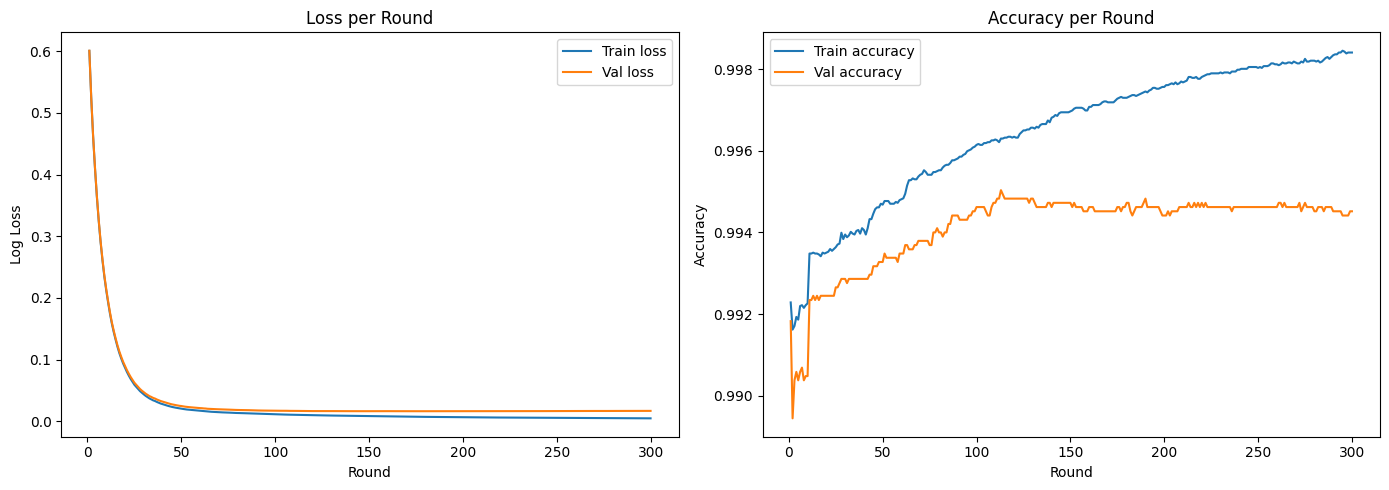

In [14]:
# Extract results
results = model.evals_result()

train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']
train_acc  = [1 - e for e in results['validation_0']['error']]
val_acc    = [1 - e for e in results['validation_1']['error']]

epochs = range(1, len(train_loss) + 1)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss, label='Train loss')
ax1.plot(epochs, val_loss,   label='Val loss')
ax1.set_title('Loss per Round')
ax1.set_xlabel('Round')
ax1.set_ylabel('Log Loss')
ax1.legend()

ax2.plot(epochs, train_acc, label='Train accuracy')
ax2.plot(epochs, val_acc,   label='Val accuracy')
ax2.set_title('Accuracy per Round')
ax2.set_xlabel('Round')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# Evaluation

                   precision    recall  f1-score   support

MITM ARP Spoofing       0.99      1.00      0.99      3880
           Normal       1.00      0.99      1.00      5789

         accuracy                           0.99      9669
        macro avg       0.99      1.00      0.99      9669
     weighted avg       0.99      0.99      0.99      9669



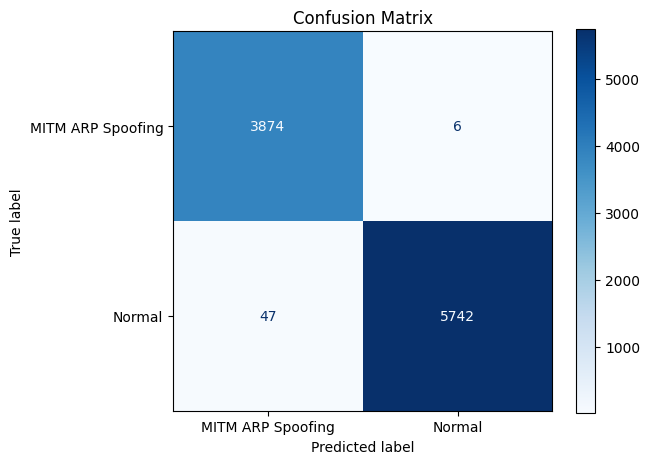

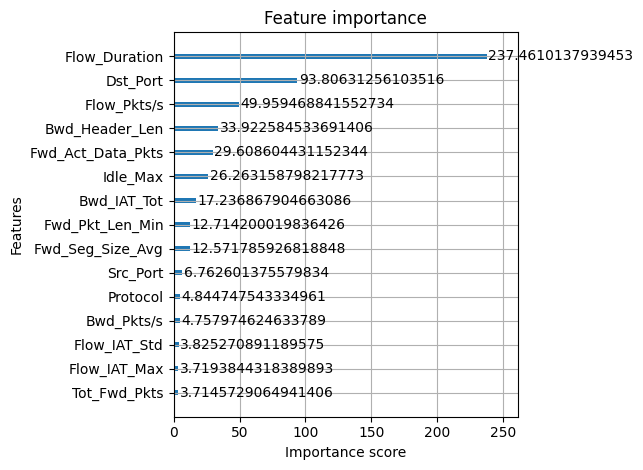

In [15]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

plot_importance(model, max_num_features=15, importance_type='gain')
plt.tight_layout()
plt.show()